In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.arima.model import ARIMA

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.7 MB/s eta 0:00:00


In [ ]:
import arch
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

In this notebook, we will analyse the implied volatility (VIX index) of the s&p500, daily data from 2007-01-03 to 2022-06-30.

In [5]:
df_full = pd.read_csv('/content/drive/MyDrive/spx_vol.csv')
df = np.log(df_full['vix'])
print(df)


0       2.488234
1       2.443216
2       2.496506
3       2.484907
4       2.477378
          ...   
3896    3.304319
3897    3.293983
3898    3.344980
3899    3.337903
3900    3.357245
Name: vix, Length: 3901, dtype: float64


Firstly, the data is visualised.

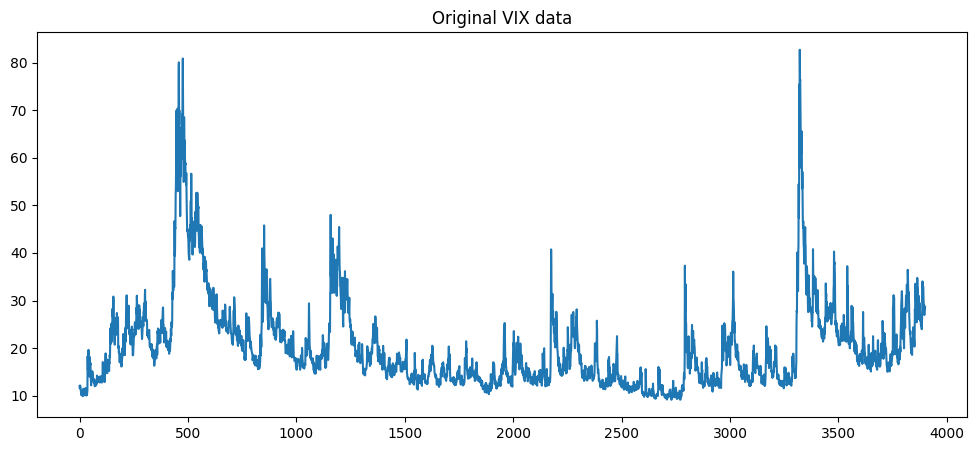

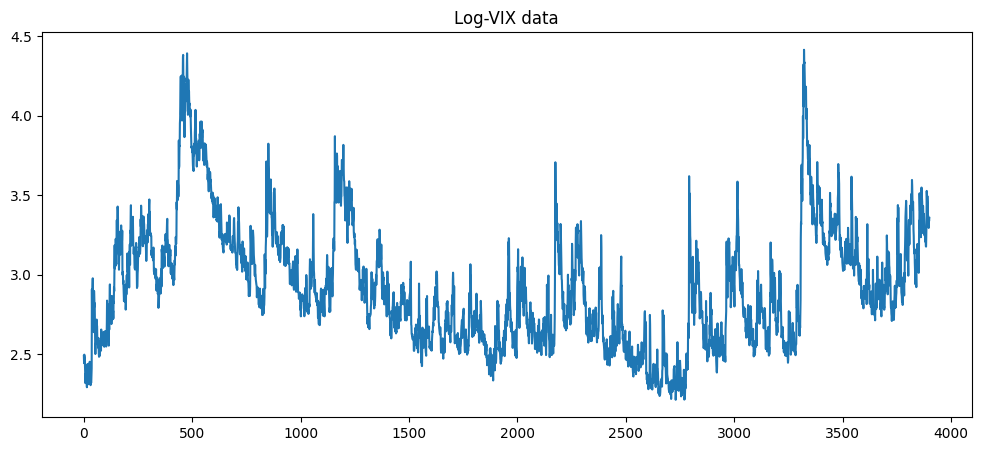

In [6]:
plt.figure(figsize=(12,5))
plt.plot(np.exp(df))
plt.title("Original VIX data")
plt.show()
plt.figure(figsize=(12,5))
plt.plot(df)
plt.title("Log-VIX data")
plt.show()

We shall begin with the decomposition into a trend, seasonality and noise parts. We are going to be using the log-VIX to smooth out the outliers.

When the series is decomposed into multiplicative parts: $y_t = T_t \cdot s_t \cdot e_t$ and a logarithm is taken, then $\ln(y_t) = \ln(T_t) + \ln(s_t) + \ln(e_t)$. The new series has additive decomposition.

We approximate the log-VIX data with normal distribution, though it has values from (0,+oo).

We have a lot of data and we suspect quartarly seasonality (one quartal = approx. 60 days) but that interval is too short for the length of the data, so try yearly seasonality (approx. 240 days, trading days)

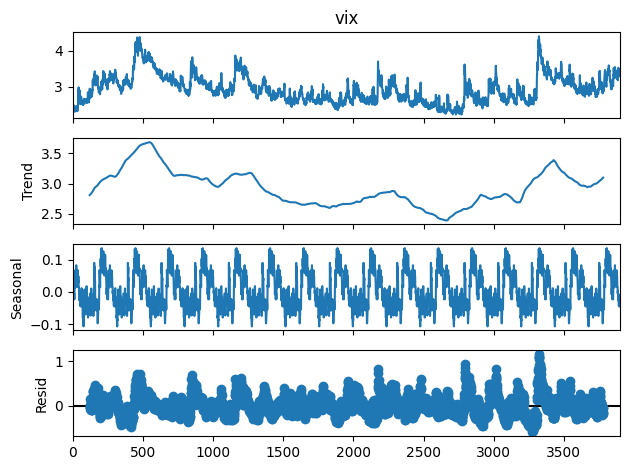

In [ ]:
result = seasonal_decompose(df, period=240, model='additive')
result.plot()
plt.show()

The autocorrelaciton and partial-autocorrelation functions (ACF, PACF) help us determine the type of AR, AMRA, ARIMA processes.

ACF, PACF are calculated using sample means, sample variance

$\bar{y} = \frac{1}{n} \sum_{i=1}^n y_i, \quad \hat{\sigma^{2}} = \sum_{i=1}^n (y_i -\bar{y})^{2}$

Then the sample autocorrelation function (ACF) at lag \(k \ge 0\) is
$$
\rho(k) =
\begin{cases}
1, & \text{if } k = 0,\\[6pt]
\frac{ \displaystyle \sum_{t=1}^{T-k} (y_{t+k} - \bar{y})(y_t - \bar{y})}{\displaystyle \sum_{t=1}^{T} (y_t - \bar{y})^2}, & \text{if } k \ge 1.
\end{cases}
$$

The partial autocorrelation at lag $k$ is defined as the last coefficient in linear regression AR(k), estimated as:
$$
y_t = \phi_0 + \phi_{1} y_{t-1} + \phi_{2} y_{t-2} + \dots + \phi_{k} x_{t-k} + \varepsilon_t,
\quad t = k+1, \dots, T,
$$

$ PACF(k) = \phi_k $

$\hat{\phi} = (X^{'}X)^{-1}X^{'}Y$

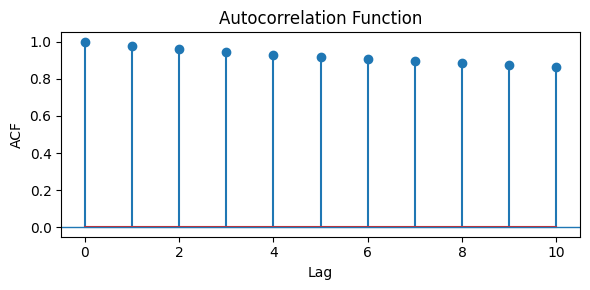

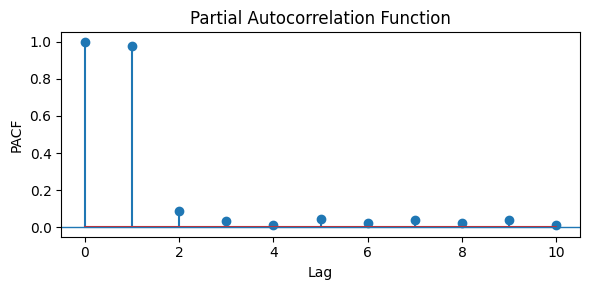

In [8]:
def acf(series, max_lag):
    x = np.asarray(series)
    mean = x.mean()
    sigma = np.sum((x - mean)**2)

    acf_vals = []
    for k in range(max_lag + 1):
        if k == 0:
            num = sigma
        else:
            num = np.sum((x[k:] - mean) * (x[:-k] - mean))
        acf_vals.append(num / sigma)
    return np.array(acf_vals)

def pacf(series, max_lag):
    x = np.asarray(series)
    pacf_vals = [1.0]

    for k in range(1, max_lag + 1):
        Y = x[k:]
        X = np.column_stack([x[k - i - 1:-(i + 1) or None] for i in range(k)])
        X = sm.add_constant(X)
        model = sm.OLS(Y, X).fit()
        pacf_vals.append(model.params[-1])
    return np.array(pacf_vals)

max_lag = 10
acf_vals = acf(df, max_lag)
pacf_vals = pacf(df, max_lag)

plt.figure(figsize=(6, 3))
lags = range(max_lag + 1)
plt.stem(lags, acf_vals)
plt.axhline(0, linewidth=1)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Autocorrelation Function")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.stem(lags, pacf_vals)
plt.axhline(0, linewidth=1)
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("Partial Autocorrelation Function")
plt.tight_layout()
plt.show()

The ACF stays high for large lag (check max_lag = 100) and slowly drops to zero. The PACF is high for the first two lags. This is not uncommon for market data.

We would like to fit a AR(p) model. p is found by comparing AR(p's) with AIC and BIC

In [ ]:
series = df
Pmax = 10

results = []

for p in range(1, Pmax + 1):
    try:
        model = AutoReg(series, lags=p, trend='c').fit()
        results.append({
            'p': p,
            'AIC': model.aic,
            'BIC': model.bic,
            'params': model.params,
            'model': model
        })
    except Exception:
        pass

df_aic_bic = pd.DataFrame(results)
print(df_aic_bic[['p', 'AIC', 'BIC']])

# Select by AIC and BIC
best_aic_row = df_aic_bic.loc[df_aic_bic['AIC'].idxmin()]
best_bic_row = df_aic_bic.loc[df_aic_bic['BIC'].idxmin()]

print(f"\nBest by AIC: AR({best_aic_row['p']})")
print(best_aic_row['params'])

print(f"\nBest by BIC: AR({best_bic_row['p']})")
print(best_bic_row['params'])


    p          AIC          BIC
0   1 -8839.362390 -8820.556195
1   2 -8864.088994 -8839.015092
2   3 -8864.481657 -8833.140562
3   4 -8860.218960 -8822.611186
4   5 -8862.347655 -8818.473715
5   6 -8859.504819 -8809.365228
6   7 -8860.675416 -8804.270686
7   8 -8859.289789 -8796.620435
8   9 -8860.085024 -8791.151561
9  10 -8855.533156 -8780.336098

Best by AIC: AR(3)
const     0.054332
vix.L1    0.890787
vix.L2    0.053494
vix.L3    0.037215
dtype: float64

Best by BIC: AR(2)
const     0.056517
vix.L1    0.893926
vix.L2    0.086823
dtype: float64


The best estimated AR models that could be selected are for p = 2 (with BIC) or p = 3 (with AIC). This is to be expected, as BIC puts larger punishment for the number of regressors.

We are going to carry on with AR(2) model because simpler models are ofter preffered and AIC for AR(2), AR(3) are not too different.

Moreover, we can easily check the stationarity using the theorem from lecture:

AR(2) process is stationary $⇔$ $\phi_2 > -1$ a $\phi_2 < 1 - \phi_1$

In [10]:
best_model = best_bic_row['model']  # or best_aic_row['model']
print(best_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                    vix   No. Observations:                 3901
Model:                     AutoReg(2)   Log Likelihood                4436.044
Method:               Conditional MLE   S.D. of innovations              0.078
Date:                Sun, 26 Oct 2025   AIC                          -8864.089
Time:                        06:24:13   BIC                          -8839.015
Sample:                             2   HQIC                         -8855.189
                                 3901                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0565      0.010      5.860      0.000       0.038       0.075
vix.L1         0.8939      0.016     56.033      0.000       0.863       0.925
vix.L2         0.0868      0.016      5.442      0.0

$\phi_ 1 = 0.8939, \phi_2 = 0.0868$, so the estimated process is indeed stationary.

All the variables are statistically significant and none of them have 0 in their $95\%$ confidence interval.

The residuals of the preffered model AR(2) are examined next.

To confirm: we reject the null hypothesis of non-stationarity of the process with the Augmented Dickey-Fuller test, which checks whether the series is stationary or has a unit root (a trend). This test uses the regression

$$\Delta y_t = \alpha + \beta_t + \gamma y_{t-1} + \sum_{i=1}^p\delta_i \Delta y_{t-i} + \varepsilon_t,$$
where $\Delta y_t = y_t - y_{t-1}$

$$H_0: \gamma = 0, H_1: \gamma < 0$$

In [ ]:
result = adfuller(series, maxlag=2, regression='c')
print(f"ADF Statistic result: {result[0]}")
print(f"p-value: {result[1]}")
print(f"used lag: {result[2]}")


ADF Statistic result: -5.628489717070348
p-value: 1.1032883175078555e-06
used lag: 2


The hypothesis $H_0$ is firmly rejected, hence the estimated process is stationary.

Next we examine the residuals of our AR(2).

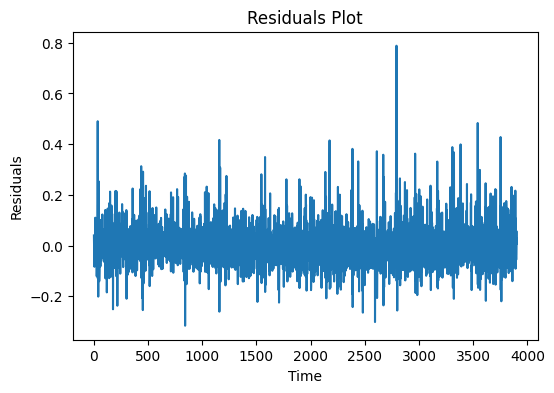

/tmp/ipython-input-3117625278.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


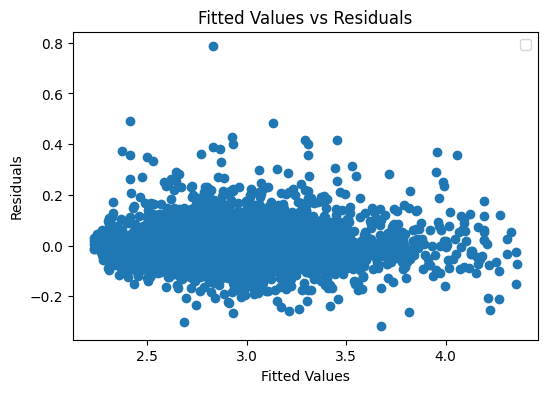

<Figure size 600x400 with 0 Axes>

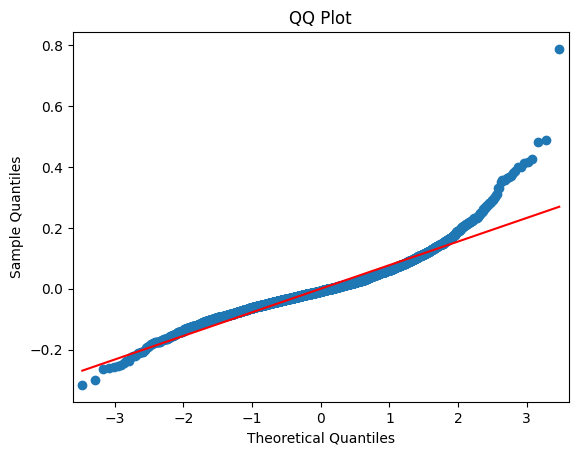

<Figure size 600x400 with 0 Axes>

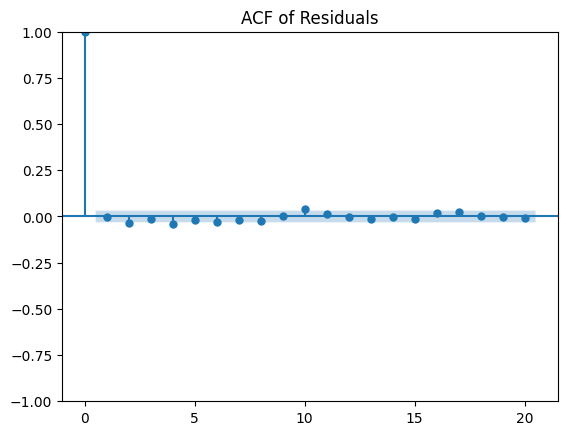

Durbin-Watson Statistic: 2.0061815334702993
Shapiro-Wilk Test Statistic: 0.9294568182107762
Shapiro-Wilk Test p-value: 1.7453544774874193e-39
Breusch–Pagan test results:
LM stat = 44.619, p-value = 0.0000
F stat  = 22.550, p-value = 0.0000


In [ ]:
residuals = best_model.resid
fitted_values = best_model.fittedvalues

def residual_analysis(res, fit_vals, x):
  plt.figure(figsize=(6, 4))
  plt.plot(res)
  plt.title('Residuals Plot')
  plt.xlabel('Time')
  plt.ylabel('Residuals')
  plt.show()

  plt.figure(figsize=(6, 4))
  plt.scatter(fit_vals, res)
  plt.title('Fitted Values vs Residuals')
  plt.xlabel('Fitted Values')
  plt.ylabel('Residuals')
  plt.legend()
  plt.show()

  plt.figure(figsize=(6, 4))
  sm.qqplot(res, line='s')
  plt.title('QQ Plot')
  plt.show()

  plt.figure(figsize=(6, 4))
  sm.graphics.tsa.plot_acf(res, lags=20)
  plt.title('ACF of Residuals')
  plt.show()

  durbin_watson_stat = durbin_watson(res)
  print(f"Durbin-Watson Statistic: {durbin_watson_stat}")
  shapiro_wilk_test = shapiro(res)
  print(f"Shapiro-Wilk Test Statistic: {shapiro_wilk_test[0]}")
  print(f"Shapiro-Wilk Test p-value: {shapiro_wilk_test[1]}")

  lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(res, x)

  print("Breusch–Pagan test results:")
  print(f"LM stat = {lm_stat:.3f}, p-value = {lm_pvalue:.4f}")
  print(f"F stat  = {f_stat:.3f}, p-value = {f_pvalue:.4f}")

X = best_model.model._x
residual_analysis(residuals, fitted_values, X)

Durbin-Watson statistics indicates no significant autocorrelation in the residuals ($DW = 2 ⇒$ no autocorrelation).

Shapiro-Wilk test rejects the null hypothesis of normality, which can be clearly seen on the QQ-plots showing heavy right tail. The examined distribution might be closer to Gamma or other extreme value distribution, not log-normal.

The fitted vs. residuals plot does not show significat heteroskedasticity but the Breusch-Pagan test rejects the null hypothesis of homoskedasticity, so the residuals are heteroskedastic. ARCH/GARCH should be considered in further analysis.

We show the in-sample fitted values and forecasts for the next quartal (approx. 60 days). Fun fact: this was a good prediction.

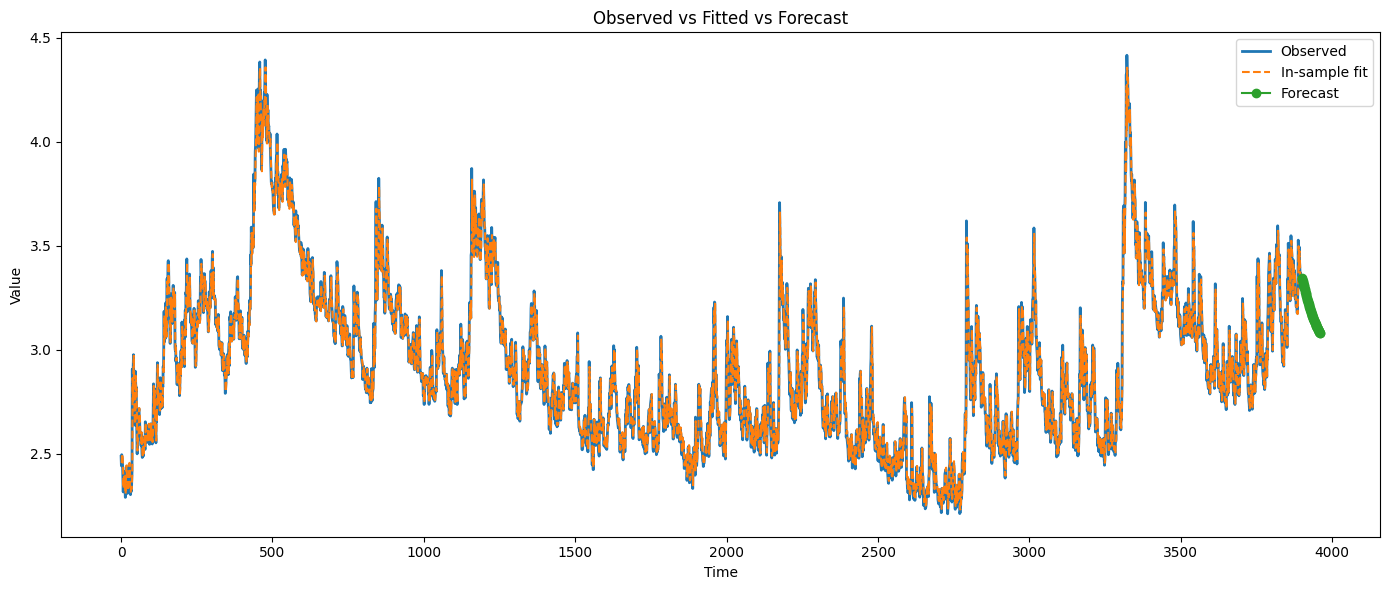

In [13]:
series = df

fitted = best_model.fittedvalues

n_forecast = 60
start = len(series)
end = start + n_forecast - 1

forecast = best_model.predict(start=start, end=end)

def plot_forecasts(series, fitted, forecast, n_forecast):
  if hasattr(series.index, "freq") and series.index.freq is not None:
      forecast_index = pd.date_range(
          start=series.index[-1],
          periods=n_forecast + 1,
          freq=series.index.freq
      )[1:]
  else:
      forecast_index = np.arange(start, end + 1)

  plt.figure(figsize=(14,6))
  plt.plot(series.index, series, label="Observed", linewidth=2)
  plt.plot(fitted.index, fitted, label="In-sample fit", linestyle="--")
  plt.plot(forecast_index, forecast, label="Forecast", marker="o")

  plt.title("Observed vs Fitted vs Forecast")
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.legend()
  plt.tight_layout()
  plt.show()

plot_forecasts(series, fitted, forecast, n_forecast)



Before we move onto GARCH, we estimate ARMA models and compare them with AIC, BIC. (This step is not too optimised and runs longer.)

In [ ]:
p_values = range(0, 4)
q_values = range(0, 4)

results = []

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(series, order=(p, 0, q))
            fit = model.fit()
            results.append({
                'order': (p, q),
                'aic': fit.aic,
                'bic': fit.bic
            })
        except:
            pass

df_results = pd.DataFrame(results).sort_values('aic')
print(df_results.head())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels

     order          aic          bic
10  (2, 2) -8883.074600 -8845.460671
11  (2, 3) -8882.033811 -8838.150893
15  (3, 3) -8881.327148 -8831.175242
14  (3, 2) -8881.283199 -8837.400281
9   (2, 1) -8873.752934 -8842.407993


In [15]:
best_order = df_results.iloc[0]['order']
best_arma = ARIMA(series, order=(best_order[0], 0, best_order[1])).fit()
print(best_arma.summary())


                               SARIMAX Results                                
Dep. Variable:                    vix   No. Observations:                 3901
Model:                 ARIMA(2, 0, 2)   Log Likelihood                4447.537
Date:                Sun, 26 Oct 2025   AIC                          -8883.075
Time:                        06:25:49   BIC                          -8845.461
Sample:                             0   HQIC                         -8869.724
                               - 3901                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9226      0.086     34.010      0.000       2.754       3.091
ar.L1          1.7138      0.085     20.279      0.000       1.548       1.879
ar.L2         -0.7171      0.083     -8.627      0.0

We see that the ma2 coefficient is not statistically significant and $0$ lies in its $95\%$ confidence interval. What should be used instead is: ARIMA(2,0,1) = ARMA(2,1): AR(2) component + MA(1) (simple exponencial smoothing)

In [16]:
model_21 = ARIMA(series, order=(2, 0, 1)).fit()
print(model_21.summary())

                               SARIMAX Results                                
Dep. Variable:                    vix   No. Observations:                 3901
Model:                 ARIMA(2, 0, 1)   Log Likelihood                4441.876
Date:                Sun, 26 Oct 2025   AIC                          -8873.753
Time:                        06:26:08   BIC                          -8842.408
Sample:                             0   HQIC                         -8862.628
                               - 3901                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9224      0.071     41.198      0.000       2.783       3.061
ar.L1          1.3577      0.101     13.475      0.000       1.160       1.555
ar.L2         -0.3683      0.098     -3.739      0.0

The "Heteroskedasticity (H): 1.34" from the model summary indicates mild heteroskedasticity in residuals (first half of the series is has about 34\% higher variance).

The estimated variance in the model fit is $\hat{\sigma}^2= 0.006$

So far, the best estimated model is the ARMA(2,1).

The heteroskedasticity should be adressed. We move on to GARCH model, where we fit GARCH on the residuals on the estimated ARMA(2,1) to model the conditional variance.

Let $\hat{\varepsilon}_t$ be the residuals from the mean model.
In GARCH, it is assumed that
$$\hat{\varepsilon}_t = \sigma e_t, \quad e_t \sim N(0,1) \quad iid$$
$$\sigma^2_t = \omega + \alpha \hat{\varepsilon}_t^2 + \beta \sigma^2_{t-1} $$


/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006046. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                4881.99
Distribution:      Standardized Student's t   AIC:                          -9755.99
Method:                  Maximum Likelihood   BIC:                          -9730.91
                                              No. Observations:                 3901
Date:                      Sun, Oct 26 2025   Df Residuals:                     3901
Time:                              06:27:01   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

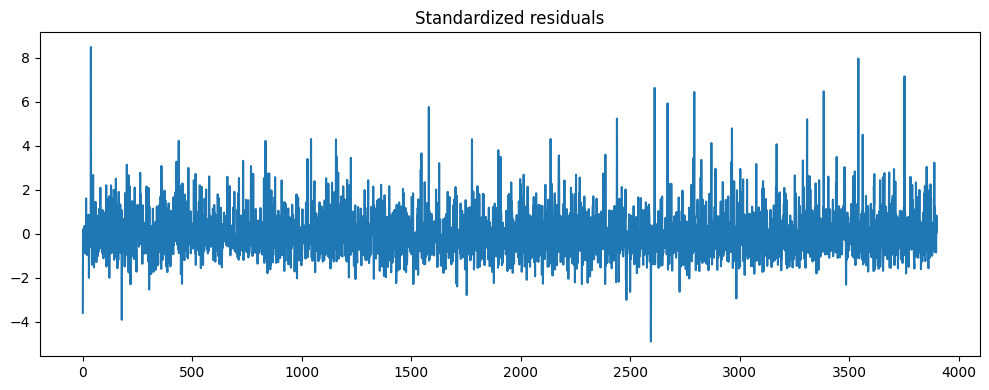

<Figure size 1000x400 with 0 Axes>

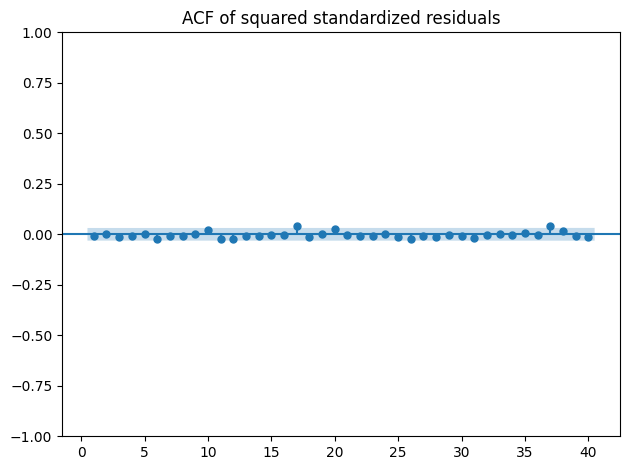

<Figure size 600x600 with 0 Axes>

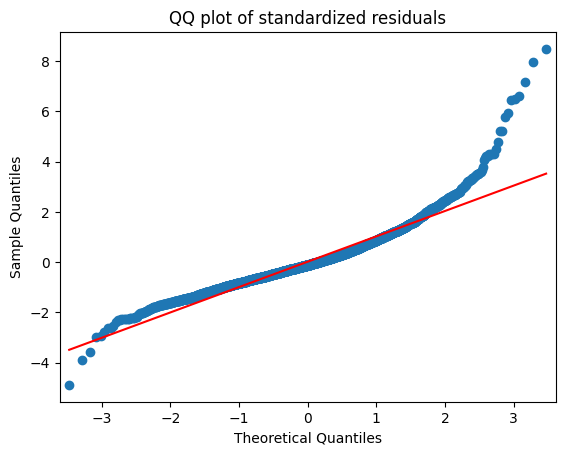

In [ ]:
resid = model_21.resid.dropna()

# fit GARCH(1,1) on residuals
garch11 = arch_model(resid, vol='GARCH', p=1, q=1, mean='Zero', dist='t')
garch_res = garch11.fit(update_freq=10, disp='off')
print(garch_res.summary())

alpha = garch_res.params['alpha[1]']
beta  = garch_res.params['beta[1]']
print("alpha+beta =", alpha + beta)
if alpha + beta < 1:
    omega = garch_res.params['omega']
    print("Unconditional variance:", omega / (1 - alpha - beta))

# diagnostics
std_resid = garch_res.std_resid
lm_stat, lm_pvalue, _, _ = het_arch(std_resid, nlags=12)
print("ARCH LM p-value on std_resid:", lm_pvalue)

plt.figure(figsize=(10,4))
plt.plot(std_resid); plt.title("Standardized residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sm.graphics.tsa.plot_acf(std_resid**2, lags=40, zero=False)
plt.title("ACF of squared standardized residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
sm.qqplot(std_resid, line='s')
plt.title('QQ plot of standardized residuals')
plt.show()


$\alpha + \beta < 1$, which indicates stationary conditional variance in GARCH(1,1). ARCH LM $ p-value > 0.05 \Rightarrow$ GARCH(1,1) captures conditional heteroskedasticity.

The standardized residual plots indicate zero mean, iid behavior. Heavy right tail remains.

Since the GARCH models the variance of the residuals, plotting the standard deviation can give an idea of the expected volatility around the mean forecast.

We can plot the mean forecast $\pm$ $\hat{\sigma}$, from the GARCH forecast.

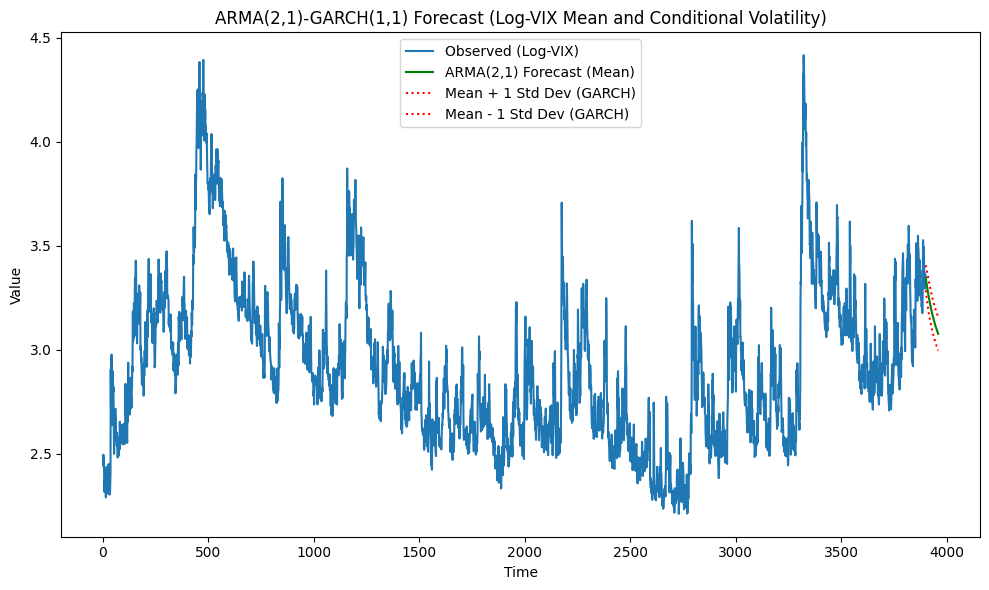

In [24]:
n_forecast_garch = 60
garch_forecast = garch_res.forecast(horizon=n_forecast_garch, reindex=False)

arma_forecast_mean = model_21.predict(start=len(series), end=len(series) + n_forecast_garch - 1)

forecast_log_vix = arma_forecast_mean
forecast_vix_volatility = np.sqrt(garch_forecast.variance.values[-1, :])

# Plotting the forecast
plt.figure(figsize=(10, 6))
plt.plot(series.index, series, label="Observed (Log-VIX)")
plt.plot(arma_forecast_mean.index, forecast_log_vix, label="ARMA(2,1) Forecast (Mean)", linestyle="-", color='green')

forecast_index_garch = pd.RangeIndex(start=len(series), stop=len(series) + n_forecast_garch)

plt.plot(forecast_index_garch, forecast_log_vix + forecast_vix_volatility, label="Mean + 1 Std Dev (GARCH)", color='red', linestyle='dotted')
plt.plot(forecast_index_garch, forecast_log_vix - forecast_vix_volatility, label="Mean - 1 Std Dev (GARCH)", color='red', linestyle='dotted')


plt.title("ARMA(2,1)-GARCH(1,1) Forecast (Log-VIX Mean and Conditional Volatility)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## FINAL MODEL
The final model is an ARMA(2,1) process for the mean, with a GARCH(1,1) model for the conditional variance of residuals, using a student-t distribution for innovations. The model captures both autocorrelation in the series and volatility clustering, with standardized residuals approximately iid but heavy-tailed

## RLS

We model the log-realized volatility as a linear function of lagged log-VIX values and a moving average of those values.

Let $y_t = \log(\text{w}_t)$, $w_t$ is the real volatility data and let $v_t$ denote the VIX series.

We construct the regressor
vector $x_t \in \mathbb{R}^4$ as
$$
x_t =
\begin{bmatrix}
1 \\
v_{t-1} \\
v_{t-2} \\
\frac{1}{m}\sum_{i=0}^{m-1} v_{t-i}
\end{bmatrix},
\quad m = 20.
$$
To match the ARMA(2,1)-like estimation.


Hence, the examined regression is
$$
y_t = \beta_0 + \beta_1 v_{t-1} + \beta_2 v_{t-2} + \beta_3 \frac{1}{m}\sum_{i=0}^{m-1} v_{t-i} + \varepsilon_t,
$$

$\varepsilon_t \sim N(0, \sigma^2)$

We apply Recursive Least Squares (RLS) with forgetting factor $\lambda = 0.98$. Low $\lambda$ values ($\lambda \in (0.7, 0.9)$) tends to 'overfit' the current data, while very high values ($\lambda \in (0.98, 0.999)$) tends to stable parameters $\beta$ estimates.

For $t = 1, 2, \dots, T$, we update the parameter vector $\hat{\beta}_t$ as follows.

Let $\hat{\beta}_{t-1}$ be the previous estimate
and $P_{t-1}$ the corresponding covariance matrix. Then,
$$
K_t = \frac{P_{t-1} x_t}{\lambda + x_t^\top P_{t-1} x_t},
$$

$$
\hat{\beta}_t = \hat{\beta}_{t-1} + K_t \bigl(y_t - x_t^\top \hat{\beta}_{t-1}\bigr),
$$

$$
P_t = \frac{1}{\lambda}\Bigl(P_{t-1} - K_t x_t^\top P_{t-1}\Bigr).
$$

The one-step-ahead prediction is
$$
\hat{y}_t = x_t^\top \hat{\beta}_{t-1}.
$$

We initialize $\hat{\beta}_0 = \mathbf{0}$ and $P_0 = 10.0 \, Id$ to represent a diffuse prior.


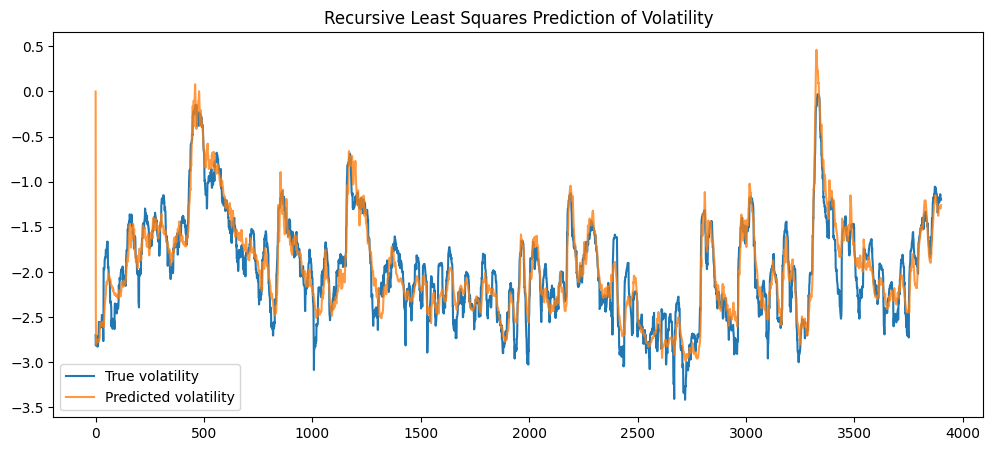

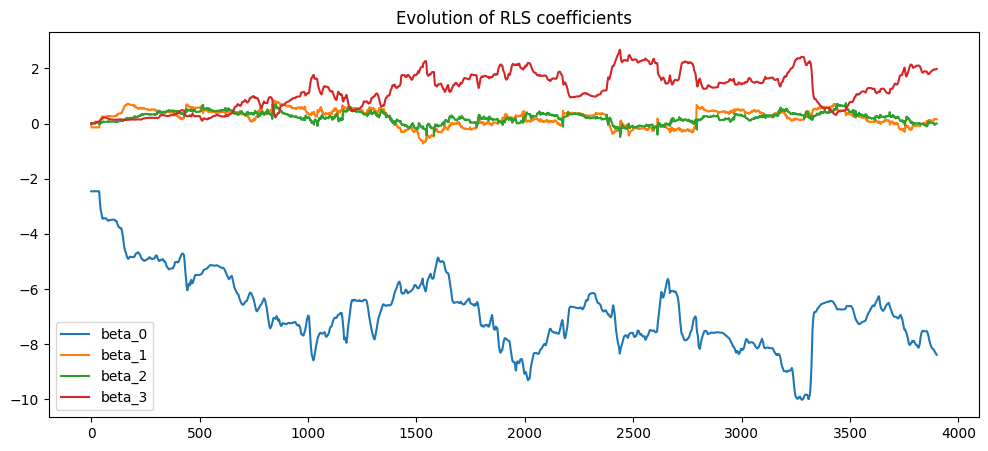

===Estimated ARMA(2,1) model paramaters:===

----------------------------------------------

intercept: -8.384837470493398 
lag-1: 0.1567013404607116 
lag-2: -0.00013794559845245984 
20-lag moving average: 1.9802951411775571

MSE: 0.041975607325495885

Variance in True Volatility Data: 0.31150850806682945

 Covariance matrix: [[ 2.88330157 -0.23655844  0.10838643 -0.77710332]
 [-0.23655844  1.51886698 -1.35282244 -0.09293869]
 [ 0.10838643 -1.35282244  1.70397815 -0.38627875]
 [-0.77710332 -0.09293869 -0.38627875  0.72646633]]


In [32]:
df_real_vol = np.log(df_full['sp20vol'])

lambda_factor = 0.99
window_ma = 20

vix = df
y_true = df_real_vol

T = len(vix)
X = np.zeros((T, 4))
X[:, 0] = 1  # intercept
X[1:, 1] = vix[:-1]           # lag 1
X[2:, 2] = vix[:-2]           # lag 2
X[window_ma-1:, 3] = pd.Series(vix).rolling(window=window_ma).mean().values[window_ma-1:]  # moving avg

n = X.shape[1]
beta_hat = np.zeros(n)
P = np.eye(n) * 10.0  # initial large uncertainty

y_pred = np.zeros(T)
resid_rls = np.zeros(T)
beta_arr = []

# --- Recursive Least Squares ---
for t in range(T):
    x_t = X[t][:, np.newaxis]
    y_pred[t] = beta_hat @ X[t]

    # obtain residual
    e_t = y_true[t] - y_pred[t]
    resid_rls[t] = e_t

    # Update beta_hat
    denom = lambda_factor + (x_t.T @ P @ x_t)[0,0]
    K = (P @ x_t) / denom
    beta_hat = beta_hat + (K.flatten() * (y_true[t] - y_pred[t]))
    P = (P - K @ x_t.T @ P) / lambda_factor
    beta_arr.append(beta_hat.copy())


mse = np.mean((y_pred - y_true)**2)

plt.figure(figsize=(12,5))
plt.plot(y_true, label='True volatility')
plt.plot(y_pred, label='Predicted volatility', alpha=0.8)
plt.legend()
plt.title('Recursive Least Squares Prediction of Volatility')
plt.show()

beta_arr = np.array(beta_arr)
plt.figure(figsize=(12,5))
for i in range(n):
    plt.plot(beta_arr[:, i], label=f'beta_{i}')
plt.title('Evolution of RLS coefficients')
plt.legend()
plt.show()

print("===Estimated ARMA(2,1) model paramaters:===\n")
print("----------------------------------------------\n")
print("intercept:", beta_hat[0], "\nlag-1:", beta_hat[1], "\nlag-2:", beta_hat[2], f"\n{window_ma}-lag moving average:", beta_hat[3])
print("\nMSE:", mse)
print("\nVariance in True Volatility Data:", df_real_vol.var())

print("\n Covariance matrix:", P)


We use the code from above to analyze the residuals, where we have to omitt the first value (estimated using improper prior).

In [33]:
print(X[1:].shape)
print(y_pred[1:].shape)

(3900, 4)
(3900,)


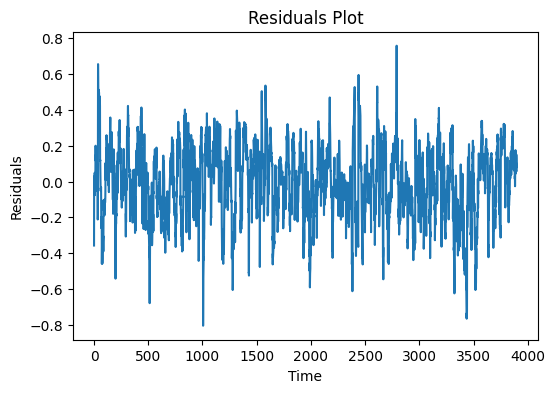

/tmp/ipython-input-3117625278.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


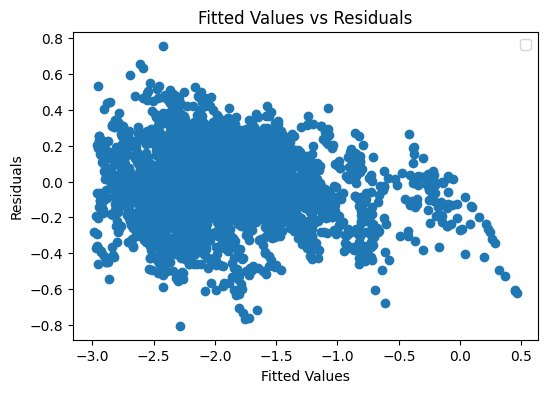

<Figure size 600x400 with 0 Axes>

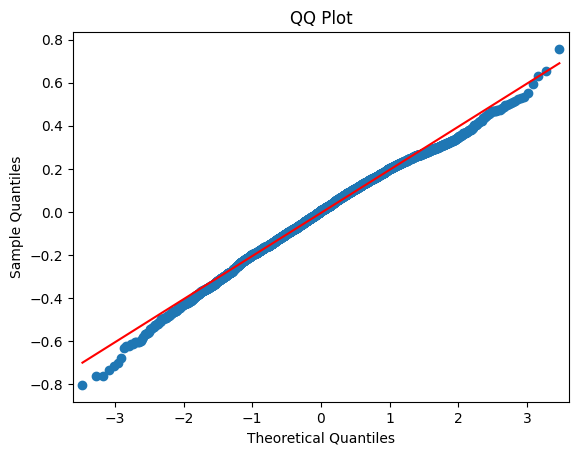

<Figure size 600x400 with 0 Axes>

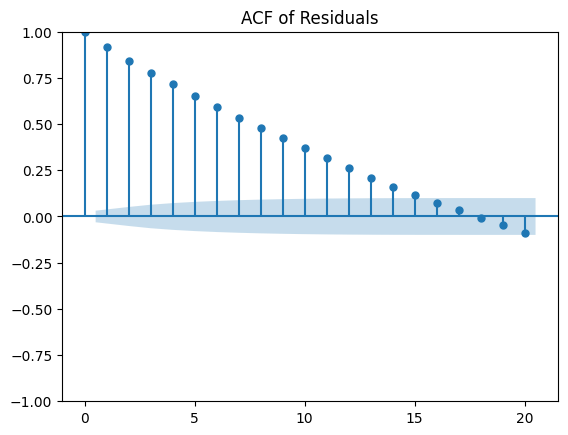

Durbin-Watson Statistic: 0.16276839845373978
Shapiro-Wilk Test Statistic: 0.9943498490450783
Shapiro-Wilk Test p-value: 3.414640023863371e-11
Breusch–Pagan test results:
LM stat = 20.464, p-value = 0.0001
F stat  = 6.850, p-value = 0.0001


In [34]:
residual_analysis(resid_rls[1:], y_pred[1:], X[1:])

The residuals exhibit strong autocorrelation, slight non-normality and some evidence of heteroskedasticity.

At last we make a forecast for the realised S&P500 volatility using the estimated RLS model. These forecasts are very similar to the forecasts obtained for the VIX with the AMRMA, GARCH models, though dependant on the current $\hat{\beta}$ estimate.

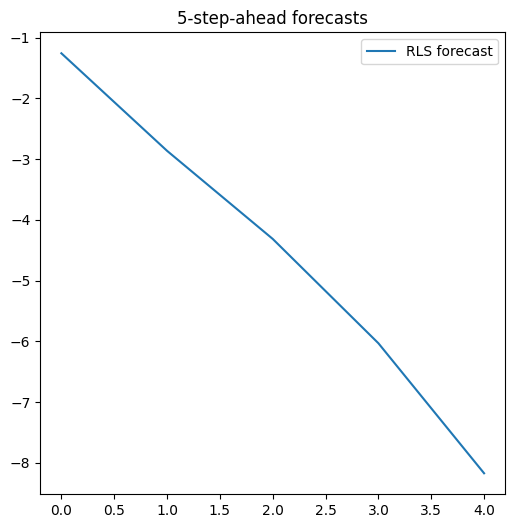

In [ ]:
h = 5  # number of steps ahead to forecast
last_vix = vix.values[-2:]
last_ma_window = vix.values[-window_ma:]
n = len(beta_hat)

y_forecast = np.zeros(h)

# Forecast recursively
for t in range(h):
    x_t = np.zeros(n)
    x_t[0] = 1
    x_t[1] = last_vix[-1]
    x_t[2] = last_vix[-2]
    ma_input = np.append(last_ma_window, y_forecast[:t])  # append predicted values
    x_t[3] = ma_input[-window_ma:].mean()

    # predict
    y_pred = beta_hat @ x_t
    y_forecast[t] = y_pred

    # update lag vectors for next step
    last_vix = np.append(last_vix[1:], y_pred)
    last_ma_window = np.append(last_ma_window[1:], y_pred)

plt.figure(figsize=(6,6))
plt.title(f"{h}-step-ahead forecasts")
plt.plot(y_forecast, label="RLS forecast")
plt.legend()
plt.show()


### CONCLUSIONS
The best estimated model is the ARMA(2,1) + GARCH(1,1) that models the mean and captures the variance in the VIX data. Though some heteroskedasticity and heavy right tail persists. The AR(2) model confirmed that the underlying process is stationary in lag 2, which is common in financial data, leading to 'degenerated' forecasts, that are possibly valid only for few step-ahead predictions.

We have also tried to model the realised volatility directly using Recurrent Least Squares (RLS) with lag 2 and 20 lag moving average in the regressor (with VIX data). We tried these lags in the moving average for RLS: 2, 5, 10, 20, 50. 20 gave the best and most stable $\beta$ estimates for the given data. The forgretting factor $\lambda$ allows to model slowly varying parameters (also variance $\sigma^2$) but still fails to capture all of the heteroskedasticity.

In conlusion normal distribution is not a good fit for the log-VIX data, which exhibits behavior closer to some extreme value distribution. Ppossibly Gamma distribution could be beneficial.

## Future Work

In the following project I would like to explore these ideas.

- Kalman filters (from next classes), possibly regime switching models
- Predicting option prices using the estimated models of the realised volatility
- Using FFT to explore the possible cyclic nature of the markets

## ChatGPT oppinion/recommendation on future works
(my preference highlighted in bold)

🧭 0 Immediate Extensions — Advanced Time Series Structure

Focus: deepening the econometric rigor of your volatility model.
Ideas:

State-Space & Kalman Filters:

- Convert your RLS or ARIMA model into a state-space representation.

- Estimate time-varying parameters ($\beta_t$) and latent volatility.

- This makes your model adaptive — ideal for fast-moving financial series like VIX.

Mixed or Hierarchical Models:

- Combine macro variables (e.g., interest rates, FX indices) as exogenous regressors.

- Hierarchical structures let you pool information across assets (e.g., VIX, VVIX, sector indices).

⚡ $\textbf{1 Volatility Dynamics and Option Pricing Links}$

Focus: directly connecting volatility forecasts with options prices.
Ideas:

- Use your forecasted volatility to price options via Black–Scholes or Heston model:
$$𝐶_𝑡=𝐵𝑆(𝑆_𝑡,𝐾,𝑟,𝑇,\hat{\sigma}_{𝑡→𝑇}),$$
where $\hat{\sigma}_{𝑡→𝑇}$ comes from your volatility model.

- Evaluate implied volatility surfaces vs. your predicted volatility to detect mispricings.

- Design a volatility trading strategy (e.g., VIX futures spread, straddle/strangle optimization).

🤖 $\textbf{2 Deep Learning and Hybrid Methods}$

Focus: blending your econometric base with machine learning.
Ideas:

- RNNs / LSTMs: use your volatility, lags, and macro inputs as features to predict realized volatility or implied vol changes.

- Hybrid models: ARIMA–LSTM or GARCH–RNN combinations (residual modeling or volatility refinement).

- Attention mechanisms: emphasize time periods with shocks (e.g., crisis detection for option strategy risk).

💡 3 Strategic Applications

Focus: applying predictive models in trading or hedging.
Ideas:

- Use forecasts to optimize delta–vega neutral option portfolios.

- Predict term structure of implied volatility for calendar spread strategies.

- Build an early-warning indicator of volatility spikes (risk management use case).

🧮 4 Frequency Domain and Spectral Analysis

Focus: uncovering hidden cycles or frequencies in volatility.
Ideas:

- Use FFT or wavelet transforms to decompose volatility into cyclical components.

- Combine this with GARCH or ARMA residuals to detect volatility regimes.

 - Spectral features can also feed into your RLS or neural models.